# Liu (2025) Cross-Sectional Recreation — v10

Clean rebuild using `liu_exact_replication_v2.csv` (April 2026 pipeline) +
`liu_exact_replication_v2_IFG_addon.csv` (May 2026 IFG add-on).

**Figures:**
- Fig 2C–H — Per-subject ROI peak scatter (incl. IFG)
- Fig 2I/J  — Spatial topography Crawford *t* (lateralization-sensitive chain;
  IFG NOT in chain — frontal, not ventral)
- Fig 2I/J per-cat — Per-category Crawford *t* (top-level cats only — no IFG)
- Fig 3A/B  — Example RDMs (1×5: ctrl LH | LH-pt mean | ctrl RH | RH-pt mean | TC RH)
- Fig 3D    — Per-ROI Fisher-z boxplots (incl. l/r IFG at outermost positions)
- Fig 3E    — Per-ROI Crawford *t* (incl. IFG)
- Fig 3E′   — Per-category-pair Crawford *t* (IFG paired with word)
- Sum-selectivity — Top-level cats only — no IFG pooled into 'word' (frontal vs
  ventral kept separate)

**IFG integration rule:** any cell that shows individual sub-ROIs (face_FFA,
face_STS, etc.) includes word_IFG. Any cell that shows only the four top-level
categories (face/house/object/word) does not.

**Liu overlap:** sub-004 (UD), sub-021 (TC), sub-007 (OT)


## 1. Setup

In [20]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE    = Path(processed_dir)
LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/liu_exact_replication_v2.csv')
FIG_DIR = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact')
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE     = ['sub-017']
EXCLUDE_SES = [('sub-108', 2)]
LIU_CODES   = {'sub-004': 'UD', 'sub-021': 'TC', 'sub-007': 'OT',
               'sub-044': 'SN', 'sub-099': 'KN'}

# Build SUB_CODES from sub_info.csv: code if available, else sub-XXX number
_info_df = pd.read_csv('/user_data/csimmon2/git_repos/sym_pt/sub_info.csv')
SUB_CODES = {row['sub']: (row['code'] if pd.notna(row['code']) and row['code'] != '' else row['sub'].replace('sub-', ''))
             for _, row in _info_df.drop_duplicates('sub').iterrows()}

# FDR: 'bh' = Benjamini-Hochberg (liberal); 'by' = Benjamini-Yekutieli (Liu's choice);
# None = disable correction.
FDR_METHOD = 'bh'

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'LIU_CSV : {LIU_CSV}')
print(f'FIG_DIR : {FIG_DIR}')
print(f'FDR     : {FDR_METHOD}')


LIU_CSV : /user_data/csimmon2/git_repos/sym_pt/liu_exact_replication_v2.csv
FIG_DIR : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact
FDR     : bh


## 2. Load data

Controls → first session; OTC patients → last session.

- `le`: long-format (one row per subject × session × roi × pair)
- `le_summary`: one row per subject × session × roi
- `ctrl_le`/`pt_le`: session-selected summary
- `ctrl_pw`/`pt_pw`: session-selected pairwise (for RDMs)

In [21]:
le = pd.read_csv(LIU_CSV)
addon = LIU_CSV.parent / 'liu_exact_replication_v2_IFG_addon.csv'
if addon.exists():
    le = pd.concat([le, pd.read_csv(addon)], ignore_index=True)
    print(f'Merged IFG addon: +{(pd.read_csv(addon)["subject_id"]).nunique()} subj')
le = le[~le['subject_id'].isin(EXCLUDE)]
le['ses_num'] = pd.to_numeric(le['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    le = le[~((le['subject_id'] == bad_sub) & (le['ses_num'] == bad_ses))]

le_summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates().copy()

# Controls → first session
ctrl_all = le_summary[le_summary['status'] == 'control']
fs = ctrl_all.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
ctrl_le = ctrl_all.merge(fs, on='subject_id')
ctrl_le = ctrl_le[ctrl_le['ses_num'] == ctrl_le['keep']].drop(columns='keep')

# OTC patients → last session
pt_all = le_summary[le_summary['group'] == 'OTC']
ls = pt_all.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
pt_le = pt_all.merge(ls, on='subject_id')
pt_le = pt_le[pt_le['ses_num'] == pt_le['keep']].drop(columns='keep')

# Pairwise: filter le directly, NOT via le_summary
ctrl_pw = le[le['status'] == 'control'].merge(fs, on='subject_id')
ctrl_pw = ctrl_pw[ctrl_pw['ses_num'] == ctrl_pw['keep']].drop(columns='keep')
pt_pw = le[le['group'] == 'OTC'].merge(ls, on='subject_id')
pt_pw = pt_pw[pt_pw['ses_num'] == pt_pw['keep']].drop(columns='keep')

ctrl_subs = sorted(ctrl_le['subject_id'].unique())
otc_subs  = sorted(pt_le['subject_id'].unique())

print(f'Controls: {len(ctrl_subs)}')
print(f'OTC patients: {len(otc_subs)}')
print(f'  Liu overlap: {[s for s in otc_subs if s in LIU_CODES]}')
print(f'ctrl_pw rows: {len(ctrl_pw)}, pt_pw rows: {len(pt_pw)}')

Merged IFG addon: +69 subj
Controls: 38
OTC patients: 22
  Liu overlap: ['sub-004', 'sub-021', 'sub-044', 'sub-099']
ctrl_pw rows: 5092, pt_pw rows: 1474


In [22]:
print(ctrl_pw[ctrl_pw['subject_id']=='sub-018'][['category','hemi','pair']].drop_duplicates())

     category hemi          pair
268  face_FFA    l    face-house
269  face_FFA    l   face-object
270  face_FFA    l     face-word
271  face_FFA    l  house-object
272  face_FFA    l    house-word
..        ...  ...           ...
495  word_IFG    r   face-object
496  word_IFG    r     face-word
497  word_IFG    r  house-object
498  word_IFG    r    house-word
499  word_IFG    r   object-word

[122 rows x 3 columns]


## 3. Helpers

In [23]:
def crawford(x, c):
    """Crawford & Howell (1998) modified t, returns (t, p)."""
    c = np.asarray(c); c = c[~np.isnan(c)]
    if len(c) < 3 or np.isnan(x): return np.nan, np.nan
    m, sd = c.mean(), c.std(ddof=1)
    if sd == 0: return np.nan, np.nan
    t = (x - m) / (sd * np.sqrt((len(c) + 1) / len(c)))
    p = 2 * (1 - tdist.cdf(abs(t), df=len(c) - 1))
    return t, p

def fisher_z(r):
    r = np.clip(np.asarray(r, float), -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))

def fdr_correct(p_values, method='bh', alpha=0.05):
    """FDR correction. 'bh' (Benjamini-Hochberg, liberal) or 'by' (Benjamini-Yekutieli).
    Returns boolean mask of significant tests."""
    p = np.asarray(p_values, float)
    valid = ~np.isnan(p)
    p_valid = p[valid]
    n = len(p_valid)
    if n == 0: return np.zeros_like(p, bool)
    order = np.argsort(p_valid)
    ranked = p_valid[order]
    if method == 'bh':
        thresh = np.arange(1, n + 1) / n * alpha
    elif method == 'by':
        c_n = np.sum(1.0 / np.arange(1, n + 1))
        thresh = np.arange(1, n + 1) / (n * c_n) * alpha
    else:
        raise ValueError(f"method must be 'bh' or 'by', got {method!r}")
    passed = ranked <= thresh
    max_idx = np.where(passed)[0].max() if passed.any() else -1
    sig_valid = np.zeros(n, bool)
    if max_idx >= 0:
        sig_valid[order[:max_idx + 1]] = True
    sig = np.zeros_like(p, bool)
    sig[valid] = sig_valid
    return sig

def pt_intact_hemi(sub):
    sd = pt_le[pt_le['subject_id'] == sub]
    if sd.empty: return None
    intact = sd['intact_hemi'].iloc[0]
    return 'l' if intact == 'left' else 'r' if intact == 'right' else None

WORD_CATS = {'word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'}

## 4. Fig 2C–H — Per-subject ROI peak scatter (native space)

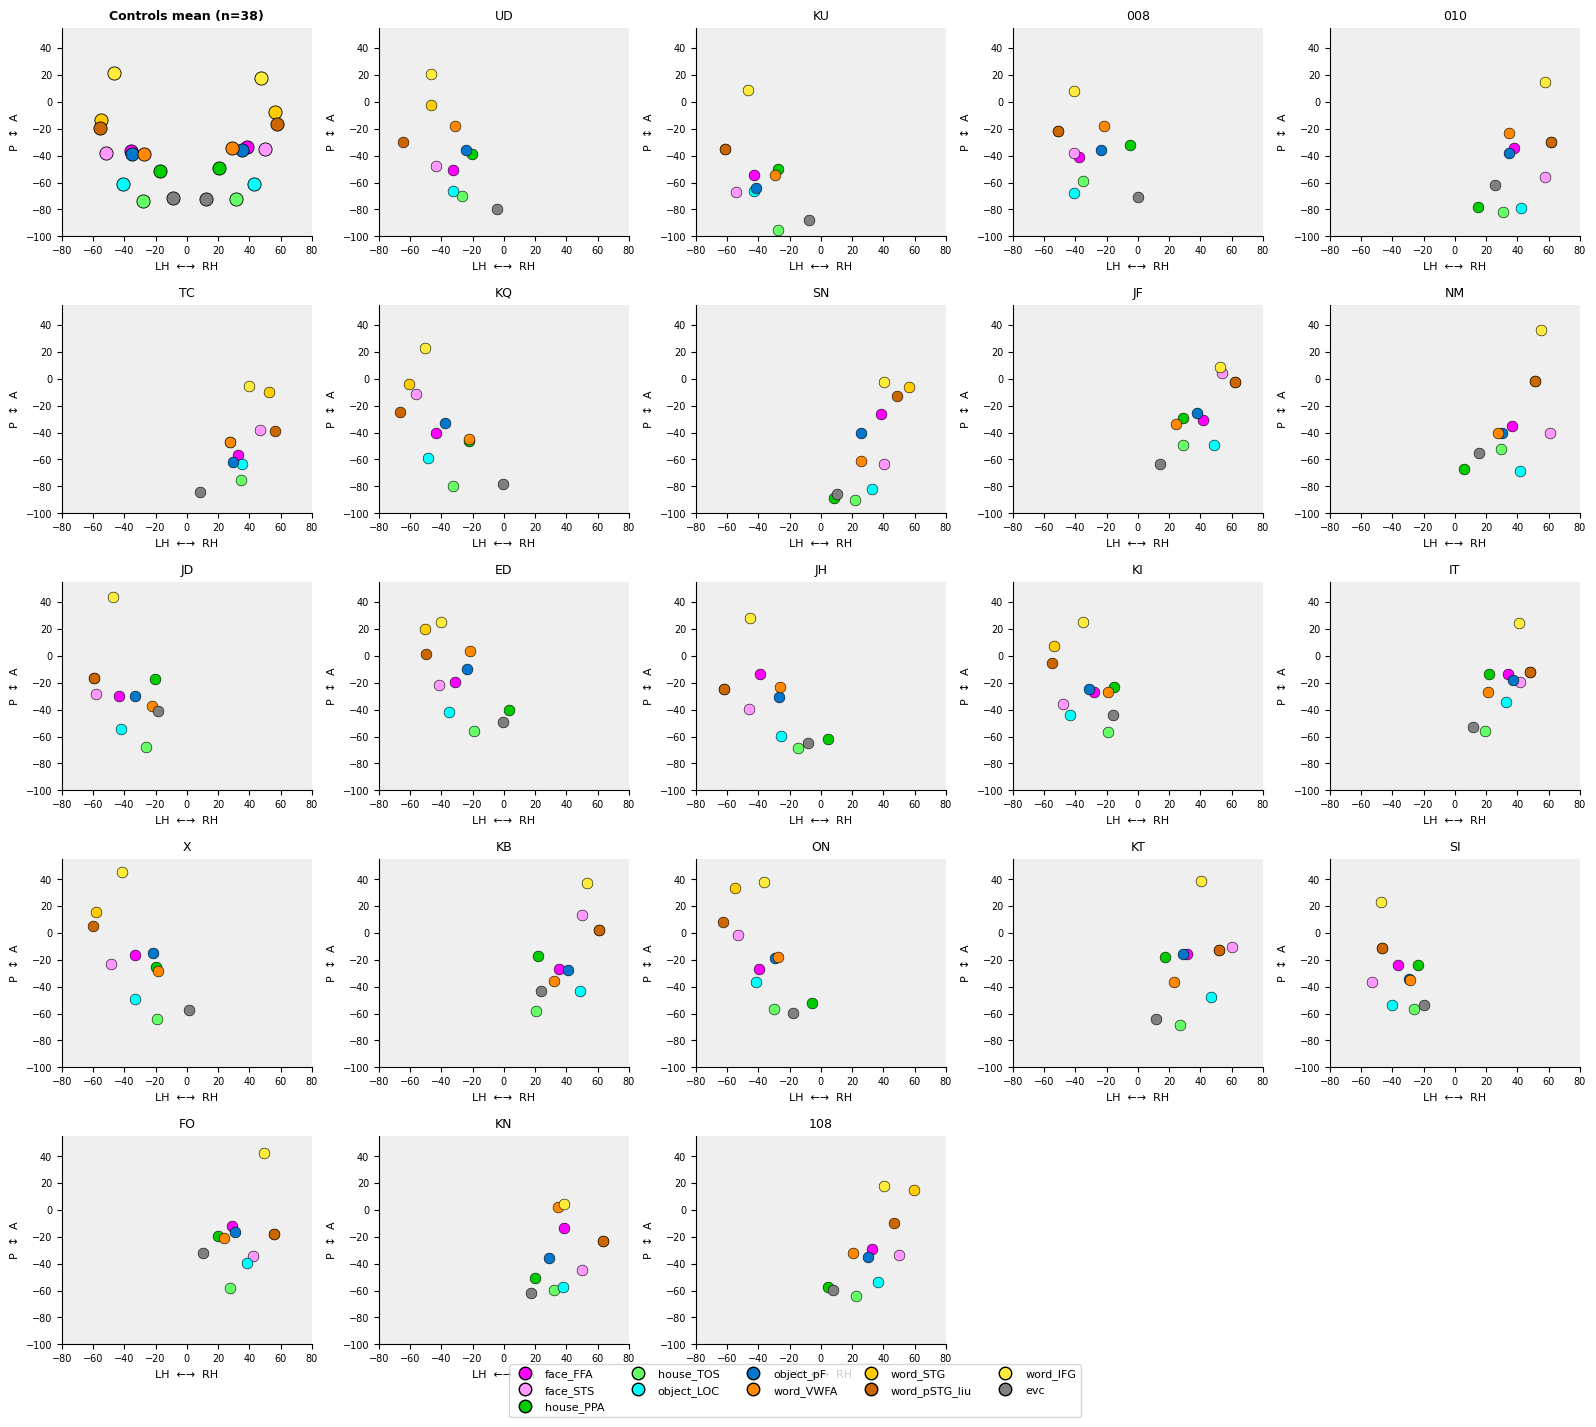

In [ ]:
ROI_COLOR = {
    'face_FFA':   'magenta',  'face_STS':    '#ff99ff',
    'house_PPA':  '#00cc00',  'house_TOS':   '#66ff66',
    'object_LOC': 'cyan',     'object_pF':   '#0077cc',
    'word_VWFA':  '#ff8800',  'word_STG':    '#ffcc00',
    'word_pSTG_liu': '#cc6600',
    'word_IFG':   '#ffeb3b',
    'evc':        'gray',
}
ALL_CATS = list(ROI_COLOR.keys())
XLIM = (-80, 80); YLIM = (-105, 55)

def scatter_subject(ax, df, sub, title):
    for cat in ALL_CATS:
        for h in ('l', 'r'):
            m = df[(df['subject_id'] == sub) & (df['category'] == cat) & (df['hemi'] == h)]
            if not len(m): continue
            ax.scatter(m['peak_x_native'].iloc[0], m['peak_y_native'].iloc[0],
                       s=60, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.4)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.set_xlabel('LH  \u2190\u2192  RH', fontsize=8)
    ax.set_ylabel('P  \u2195  A', fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_facecolor('#efefef'); ax.tick_params(labelsize=7)

n_pt  = len(otc_subs)
n_cols = 5
n_rows = int(np.ceil((n_pt + 1) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.8 * n_rows))
axes = axes.flatten()

# Controls mean (per ROI \u00d7 hemi)
ax = axes[0]
for cat in ALL_CATS:
    for h in ('l', 'r'):
        xs, ys = [], []
        for s in ctrl_subs:
            m = ctrl_le[(ctrl_le['subject_id'] == s) & (ctrl_le['category'] == cat) & (ctrl_le['hemi'] == h)]
            if len(m):
                xs.append(m['peak_x_native'].iloc[0]); ys.append(m['peak_y_native'].iloc[0])
        if xs:
            ax.scatter(np.mean(xs), np.mean(ys), s=90, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.6)
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
ax.set_title(f'Controls mean (n={len(ctrl_subs)})', fontsize=9, fontweight='bold')
ax.set_xlabel('LH  \u2190\u2192  RH', fontsize=8); ax.set_ylabel('P  \u2195  A', fontsize=8)
ax.set_facecolor('#efefef'); ax.tick_params(labelsize=7)

for i, s in enumerate(otc_subs):
    label = SUB_CODES.get(s, s.replace('sub-', ''))
    scatter_subject(axes[i + 1], pt_le, s, label)
for j in range(n_pt + 1, len(axes)):
    axes[j].axis('off')

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor='k', markersize=9, label=cat)
                  for cat, c in ROI_COLOR.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig2CH.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Fig 2I/J — Spatial topography Crawford *t*

Liu's ventral key: EVC → PPA → pF → FFA → VWFA (medial → lateral).
Correlate each subject's ventral x-coord vector with the control mean;
Crawford *t* tests patient vs control leave-one-out null.

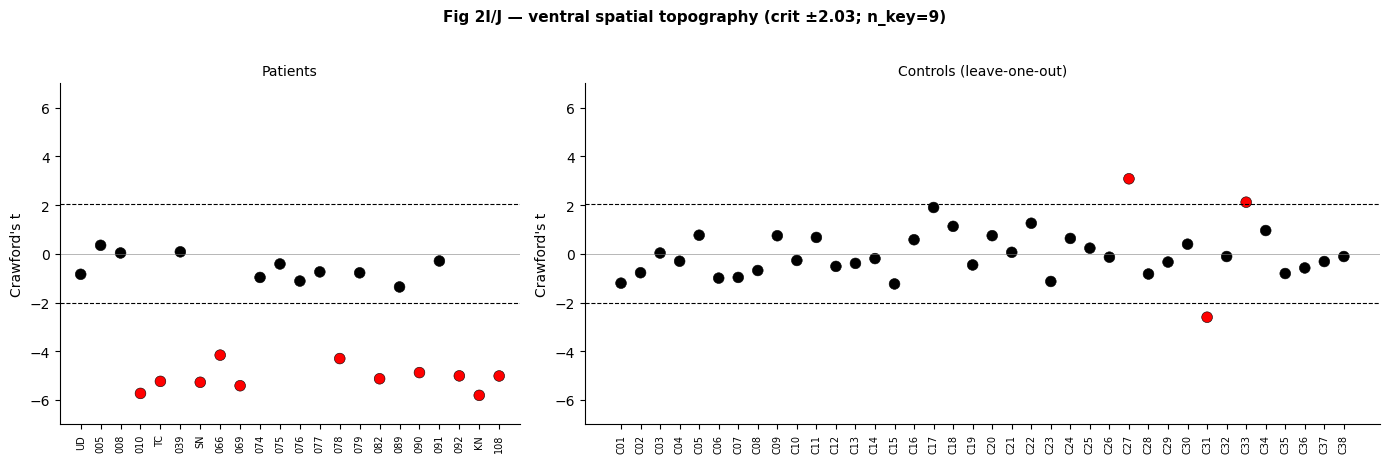

Patient t-values:    {'UD': -0.84, '005': 0.35, '008': 0.03, '010': -5.73, 'TC': -5.24, '039': 0.08, 'SN': -5.28, '066': -4.16, '069': -5.42, '074': -0.97, '075': -0.42, '076': -1.12, '077': -0.74, '078': -4.3, '079': -0.78, '082': -5.13, '089': -1.36, '090': -4.88, '091': -0.3, '092': -5.01, 'KN': -5.81, '108': -5.02}
Control t-range:     [-2.60, 3.08]


In [25]:
VENTRAL_KEY = [('evc',       'l'), ('evc',       'r'),
               ('house_PPA', 'l'), ('house_PPA', 'r'),
               ('object_pF', 'l'), ('object_pF', 'r'),
               ('face_FFA',  'l'), ('face_FFA',  'r'),
               ('word_VWFA', 'PREF')]

def resolve_hemi(hspec, is_ctrl, intact):
    if hspec in ('l', 'r'): return hspec
    if hspec == 'PREF':
        if is_ctrl: return 'l'
        return 'l' if intact == 'left' else 'r' if intact == 'right' else None
    return None

def build_xmat(df, subs, is_ctrl, intact_map):
    X = np.full((len(VENTRAL_KEY), len(subs)), np.nan)
    for i, (cat, hspec) in enumerate(VENTRAL_KEY):
        for j, s in enumerate(subs):
            h = resolve_hemi(hspec, is_ctrl, intact_map.get(s))
            if h is None: continue
            m = df[(df['subject_id'] == s) & (df['category'] == cat) & (df['hemi'] == h)]
            if len(m): X[i, j] = m['peak_x_native'].iloc[0]
    return X

intact_map = dict(zip(le_summary['subject_id'], le_summary['intact_hemi']))
X_ctrl = build_xmat(ctrl_le, ctrl_subs, True, intact_map)
X_pt   = build_xmat(pt_le,   otc_subs,  False, intact_map)
n_ctrl = len(ctrl_subs)

spcor_pt   = np.full(len(otc_subs), np.nan)
null_forpt = np.full((n_ctrl, len(otc_subs)), np.nan)
for p, s in enumerate(otc_subs):
    valid = ~np.isnan(X_pt[:, p])
    if valid.sum() < 3: continue
    pat_vec   = X_pt[valid, p]
    ctrl_sub  = X_ctrl[valid, :]
    mean_ctrl = np.nanmean(ctrl_sub, axis=1)
    ok = ~np.isnan(pat_vec) & ~np.isnan(mean_ctrl)
    if ok.sum() >= 3:
        spcor_pt[p] = np.corrcoef(pat_vec[ok], mean_ctrl[ok])[0, 1]
    for t_idx in range(n_ctrl):
        others = [c for c in range(n_ctrl) if c != t_idx]
        rest   = np.nanmean(ctrl_sub[:, others], axis=1)
        me     = ctrl_sub[:, t_idx]
        ok = ~np.isnan(me) & ~np.isnan(rest)
        if ok.sum() >= 3:
            null_forpt[t_idx, p] = np.corrcoef(me[ok], rest[ok])[0, 1]

spcor_ctrl = np.full(n_ctrl, np.nan)
for c in range(n_ctrl):
    others = [j for j in range(n_ctrl) if j != c]
    rest   = np.nanmean(X_ctrl[:, others], axis=1)
    me     = X_ctrl[:, c]
    ok = ~np.isnan(me) & ~np.isnan(rest)
    if ok.sum() >= 6:
        spcor_ctrl[c] = np.corrcoef(me[ok], rest[ok])[0, 1]

spcor_pt_fz   = fisher_z(spcor_pt)
null_pt_fz    = fisher_z(null_forpt)
spcor_ctrl_fz = fisher_z(spcor_ctrl)

t_pt   = np.array([crawford(spcor_pt_fz[p], null_pt_fz[:, p])[0] for p in range(len(otc_subs))])
t_ctrl = np.array([crawford(spcor_ctrl_fz[c], np.delete(spcor_ctrl_fz, c))[0] for c in range(n_ctrl)])

min_df = max(n_ctrl - 1, 3)
crit_2IJ = float(tdist.ppf(0.975, df=min_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                         gridspec_kw={'width_ratios': [len(otc_subs), n_ctrl]})
pt_labels   = [LIU_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
ctrl_labels = [f'C{i+1:02d}' for i in range(n_ctrl)]

ymax = max(7, int(np.ceil(max(np.nanmax(np.abs(t_pt)), np.nanmax(np.abs(t_ctrl))))) + 1)

for ax, xs, ts, labels, title in [
    (axes[0], np.arange(len(otc_subs)), t_pt, pt_labels, 'Patients'),
    (axes[1], np.arange(n_ctrl), t_ctrl, ctrl_labels, 'Controls (leave-one-out)'),
]:
    colors = ['red' if (not np.isnan(v) and abs(v) > crit_2IJ) else 'black' for v in ts]
    ax.scatter(xs, ts, s=60, c=colors, edgecolors='k', linewidth=0.4)
    ax.axhline( crit_2IJ, color='k', lw=0.8, ls='--')
    ax.axhline(-crit_2IJ, color='k', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-ymax, ymax)
    ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Crawford's t")

plt.suptitle(f'Fig 2I/J — ventral spatial topography (crit ±{crit_2IJ:.2f}; n_key={len(VENTRAL_KEY)})',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig2IJ.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Patient t-values:    {dict(zip(pt_labels, t_pt.round(2)))}')
print(f'Control t-range:     [{np.nanmin(t_ctrl):.2f}, {np.nanmax(t_ctrl):.2f}]')

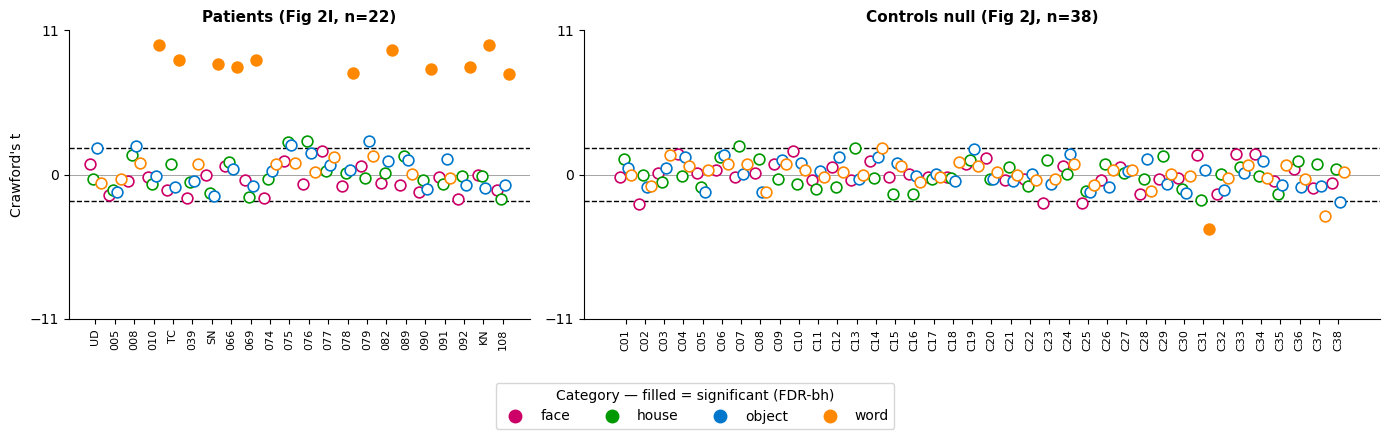

In [26]:
def get_x(df, sub, cat, h):
    m = df[(df['subject_id'] == sub) & (df['category'] == cat) & (df['hemi'] == h)]
    return m['peak_x_native'].iloc[0] if len(m) else np.nan

CAT_ROI = [
    ('face',   'face_FFA'),
    ('house',  'house_PPA'),
    ('object', 'object_pF'),
    ('word',   'word_VWFA'),
]
CAT_COLOR_2IJ = {'face': '#cc0066', 'house': '#009900',
                 'object': '#0077cc', 'word': '#ff8800'}

t_cat_pt   = {cat: np.full(len(otc_subs), np.nan) for cat, _ in CAT_ROI}
p_cat_pt   = {cat: np.full(len(otc_subs), np.nan) for cat, _ in CAT_ROI}
t_cat_ctrl = {cat: np.full(n_ctrl, np.nan) for cat, _ in CAT_ROI}
p_cat_ctrl = {cat: np.full(n_ctrl, np.nan) for cat, _ in CAT_ROI}

for cat, roi in CAT_ROI:
    for p, sub in enumerate(otc_subs):
        pt_h = pt_intact_hemi(sub)
        if pt_h is None: continue
        # Liu PREF for word (ctrl LH always); anatomic homolog for others
        ctrl_h = 'l' if cat == 'word' else pt_h
        cvals = np.array([get_x(ctrl_le, s, roi, ctrl_h) for s in ctrl_subs])
        cvals = cvals[~np.isnan(cvals)]
        if len(cvals) < 3: continue
        x = get_x(pt_le, sub, roi, pt_h)
        if np.isnan(x): continue
        t_cat_pt[cat][p], p_cat_pt[cat][p] = crawford(x, cvals)
    cvals_lh = np.array([get_x(ctrl_le, s, roi, 'l') for s in ctrl_subs])
    for c in range(n_ctrl):
        if np.isnan(cvals_lh[c]): continue
        others = np.delete(cvals_lh, c)
        others = others[~np.isnan(others)]
        if len(others) < 3: continue
        t_cat_ctrl[cat][c], p_cat_ctrl[cat][c] = crawford(cvals_lh[c], others)

min_df_2IJ = max(n_ctrl - 1, 3)
crit_2IJ = float(tdist.ppf(0.975, df=min_df_2IJ))

sig_cat_pt   = {cat: np.abs(t_cat_pt[cat])   > crit_2IJ for cat, _ in CAT_ROI}
sig_cat_ctrl = {cat: np.abs(t_cat_ctrl[cat]) > crit_2IJ for cat, _ in CAT_ROI}
if FDR_METHOD is not None:
    for cat, _ in CAT_ROI:
        sig_cat_pt[cat]   = fdr_correct(p_cat_pt[cat],   method=FDR_METHOD)
        sig_cat_ctrl[cat] = fdr_correct(p_cat_ctrl[cat], method=FDR_METHOD)

# Shared y-axis: max(|t|) across both subplots, rounded up, minimum of 7
all_vals = np.concatenate([
    np.concatenate([values[cat] for cat, _ in CAT_ROI])
    for values in [t_cat_pt, t_cat_ctrl]
])
ymax = max(7, int(np.ceil(np.nanmax(np.abs(all_vals)))) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                         gridspec_kw={'width_ratios': [len(otc_subs), n_ctrl]})
pt_labels   = [LIU_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
ctrl_labels = [f'C{i+1:02d}' for i in range(n_ctrl)]
offsets = {'face': -0.3, 'house': -0.1, 'object': 0.1, 'word': 0.3}

for ax, values, sig_map, labels, title, n_xs in [
    (axes[0], t_cat_pt,   sig_cat_pt,   pt_labels,   f'Patients (Fig 2I, n={len(otc_subs)})', len(otc_subs)),
    (axes[1], t_cat_ctrl, sig_cat_ctrl, ctrl_labels, f'Controls null (Fig 2J, n={n_ctrl})',    n_ctrl),
]:
    for cat, _ in CAT_ROI:
        xs = np.arange(n_xs) + offsets[cat]
        tv = values[cat]
        for i in range(n_xs):
            if np.isnan(tv[i]): continue
            is_sig = sig_map[cat][i]
            ax.scatter(xs[i], tv[i], s=60,
                       facecolors=CAT_COLOR_2IJ[cat] if is_sig else 'white',
                       edgecolors=CAT_COLOR_2IJ[cat], linewidth=1.2, zorder=3)
    ax.axhline( crit_2IJ, color='k', lw=1.0, ls='--')
    ax.axhline(-crit_2IJ, color='k', lw=1.0, ls='--')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_ylim(-ymax, ymax); ax.set_yticks([-ymax, 0, ymax])
    ax.set_xticks(np.arange(n_xs))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
axes[0].set_ylabel("Crawford's t")

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor=c, markersize=9, label=cat)
                  for cat, c in CAT_COLOR_2IJ.items()]
suffix = f' (FDR-{FDR_METHOD})' if FDR_METHOD else ''
plt.tight_layout()
fig.subplots_adjust(bottom=0.28)
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 0.02),
           title=f'Category — filled = significant{suffix}')
plt.savefig(FIG_DIR / 'liu_exact_fig2IJ_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Fig 3A/B — Example RDMs

Pearson *r* (Liu Fig 3 convention), vmin=0 vmax=1. Control exemplar = median word-vs-other correlation (typical).

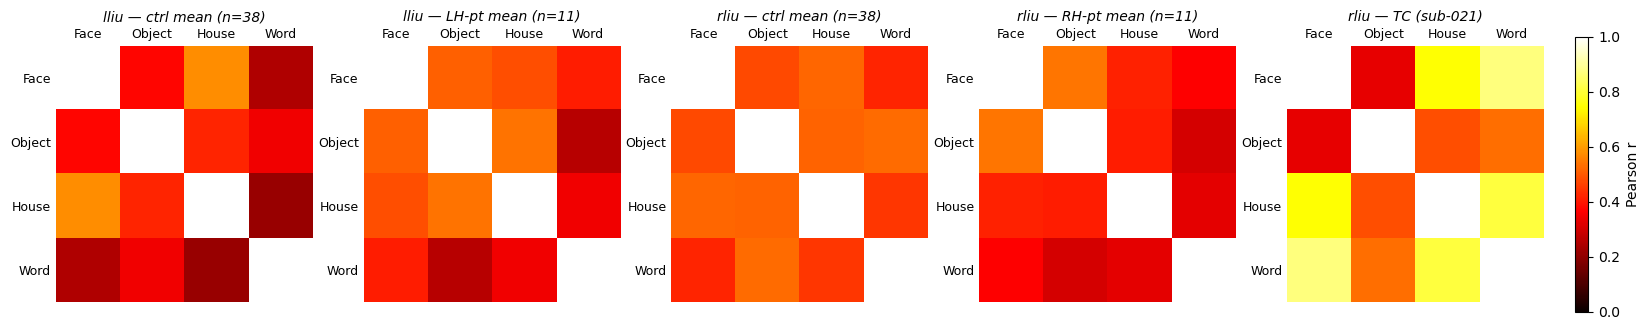

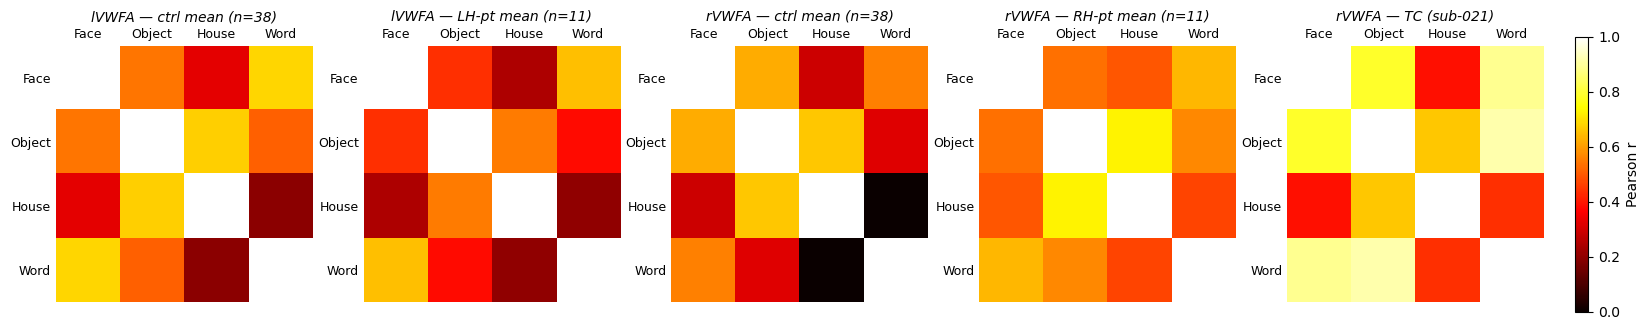

In [27]:
CATS4 = ['face', 'object', 'house', 'word']

def rdm(subj_pw):
    M = np.full((4, 4), np.nan)
    for i, a in enumerate(CATS4):
        for j, b in enumerate(CATS4):
            if i == j:
                M[i, j] = 1.0
                continue
            hit = subj_pw[subj_pw['pair'].isin([f'{a}-{b}', f'{b}-{a}'])]
            if len(hit):
                M[i, j] = np.tanh(hit['fisher_r'].iloc[0])
    return M

def mean_rdm(df, category, hemi, subjects):
    """Average RDM across subjects (each subject's RDM computed first, then averaged)."""
    rdms = []
    for s in subjects:
        sdf = df[(df['subject_id'] == s) & (df['category'] == category) & (df['hemi'] == hemi)]
        if len(sdf) == 6:
            rdms.append(rdm(sdf))
    if not rdms:
        return np.full((4, 4), np.nan), 0
    return np.nanmean(np.stack(rdms), axis=0), len(rdms)

def plot_rdm_5panel(roi, focal_sub, focal_hemi, fname):
    """1×5 layout: ctrl LH mean | LH-pt mean | ctrl RH mean | RH-pt mean | focal pt single."""
    ctrl_lh, n_lh = mean_rdm(ctrl_pw, roi, 'l', ctrl_subs)
    ctrl_rh, n_rh = mean_rdm(ctrl_pw, roi, 'r', ctrl_subs)

    # Patient groups by intact hemi
    lh_pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == 'l']  # R-resection
    rh_pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == 'r']  # L-resection
    lh_pt_rdm, n_lh_pt = mean_rdm(pt_pw, roi, 'l', lh_pt_subs)
    rh_pt_rdm, n_rh_pt = mean_rdm(pt_pw, roi, 'r', rh_pt_subs)

    # Focal patient (TC = sub-021, intact RH)
    focal_q = pt_pw[(pt_pw['subject_id'] == focal_sub) &
                    (pt_pw['category'] == roi) & (pt_pw['hemi'] == focal_hemi)]
    focal_rdm = rdm(focal_q) if len(focal_q) == 6 else np.full((4, 4), np.nan)
    focal_label = LIU_CODES.get(focal_sub, focal_sub.replace('sub-', ''))

    short = roi.split('_')[-1]
    fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
    panels = [
        (ctrl_lh,    f'l{short} — ctrl mean (n={n_lh})'),
        (lh_pt_rdm,  f'l{short} — LH-pt mean (n={n_lh_pt})'),
        (ctrl_rh,    f'r{short} — ctrl mean (n={n_rh})'),
        (rh_pt_rdm,  f'r{short} — RH-pt mean (n={n_rh_pt})'),
        (focal_rdm,  f'{focal_hemi}{short} — {focal_label} ({focal_sub})'),
    ]
    last_im = None
    for ax, (M, ttl) in zip(axes, panels):
        im = ax.imshow(M, cmap='hot', vmin=0, vmax=1, aspect='equal')
        last_im = im
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(['Face', 'Object', 'House', 'Word'], fontsize=9)
        ax.set_yticklabels(['Face', 'Object', 'House', 'Word'], fontsize=9)
        ax.xaxis.tick_top()
        ax.set_title(ttl, fontsize=10, style='italic', pad=18)
        ax.tick_params(length=0)
        for sp in ax.spines.values(): sp.set_visible(False)
    fig.colorbar(last_im, ax=axes, fraction=0.020, pad=0.02, shrink=0.85, label='Pearson r')
    plt.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

for roi, fname in [('word_pSTG_liu', 'liu_exact_fig3AB_pSTG.png'),
                   ('word_VWFA',     'liu_exact_fig3AB_VWFA.png')]:
    plot_rdm_5panel(roi, 'sub-021', 'r', fname)


## 7. Fig 3D — Per-ROI Fisher-z boxplots

Control distributions as boxes; patient markers at intact hemi. Word ROIs plotted at preferred hemi ("folded").

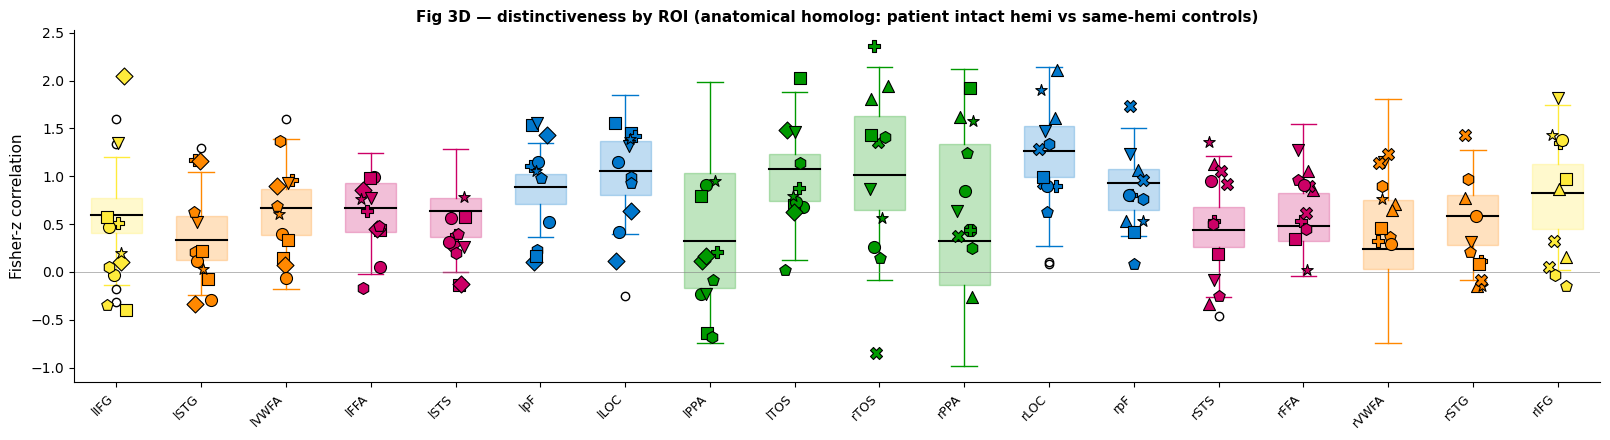

In [28]:
ROI_ORDER = [
    ('word_IFG',   'l'),
    ('word_STG',   'l'),    ('word_VWFA',  'l'),
    ('face_FFA',   'l'),    ('face_STS',   'l'),
    ('object_pF',  'l'),    ('object_LOC', 'l'),
    ('house_PPA',  'l'),    ('house_TOS',  'l'),
    ('house_TOS',  'r'),    ('house_PPA',  'r'),
    ('object_LOC', 'r'),    ('object_pF',  'r'),
    ('face_STS',   'r'),    ('face_FFA',   'r'),
    ('word_VWFA',  'r'),    ('word_STG',   'r'),
    ('word_IFG',   'r'),
]

def roi_label(roi, hspec):
    s = roi.split('_')[-1]
    return f'{hspec}{s}'

ROI_CAT_COLOR = {
    'word_STG':   '#ff8800', 'word_VWFA':  '#ff8800', 'word_pSTG_liu': '#ff8800',
    'word_IFG':   '#ffeb3b',
    'face_FFA':   '#cc0066', 'face_STS':   '#cc0066',
    'object_pF':  '#0077cc', 'object_LOC': '#0077cc',
    'house_PPA':  '#009900', 'house_TOS':  '#009900',
    'evc':        'gray',
}

_mc = ['o', 's', 'D', '^', 'v', 'P', '*', 'X', 'p', 'h']
PT_MARKERS = {s: _mc[i % len(_mc)] for i, s in enumerate(otc_subs)}

def get_distinct(df, sub, roi, hemi):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == hemi)]
    return m['liu_distinctiveness'].values[0] if len(m) else np.nan

n = len(ROI_ORDER)
fig, ax = plt.subplots(figsize=(max(14, n * 0.9), 4.5))
rng = np.random.RandomState(42)
JITTER = 0.12

for xi, (roi, hspec) in enumerate(ROI_ORDER):
    color  = ROI_CAT_COLOR[roi]
    cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == hspec)]['liu_distinctiveness'].dropna().values
    if len(cvals) == 0: continue
    ax.boxplot(cvals, positions=[xi], widths=0.6, patch_artist=True,
               medianprops={'color': 'black', 'lw': 1.5},
               whiskerprops={'color': color}, capprops={'color': color},
               boxprops={'facecolor': color, 'alpha': 0.25, 'edgecolor': color})
    # Anatomical homolog: only patients whose intact hemi matches the panel hemi
    for sub in otc_subs:
        pt_h = pt_intact_hemi(sub)
        if pt_h is None or pt_h != hspec: continue
        val = get_distinct(pt_le, sub, roi, hspec)
        if np.isnan(val): continue
        ax.scatter(xi + rng.uniform(-JITTER, JITTER), val,
                   marker=PT_MARKERS[sub], s=75, zorder=5,
                   edgecolors='black', linewidth=0.8, facecolors=color)

ax.set_xticks(np.arange(n))
ax.set_xticklabels([roi_label(c, h) for c, h in ROI_ORDER], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Fisher-z correlation', fontsize=11)
ax.axhline(0, color='gray', lw=0.4)
ax.set_title('Fig 3D — distinctiveness by ROI (anatomical homolog: patient intact hemi vs same-hemi controls)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig3D.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Fig 3E — Per-ROI Crawford *t* (with FDR)

FDR method controlled by `FDR_METHOD` in setup. `None` disables correction.

Significant (raw α=.05):     25 / 198
Significant (within-ROI FDR-bh): 7 / 198
n_ctrl per ROI: min=37, max=41
Critical t (uncorrected, df=36): ±2.028



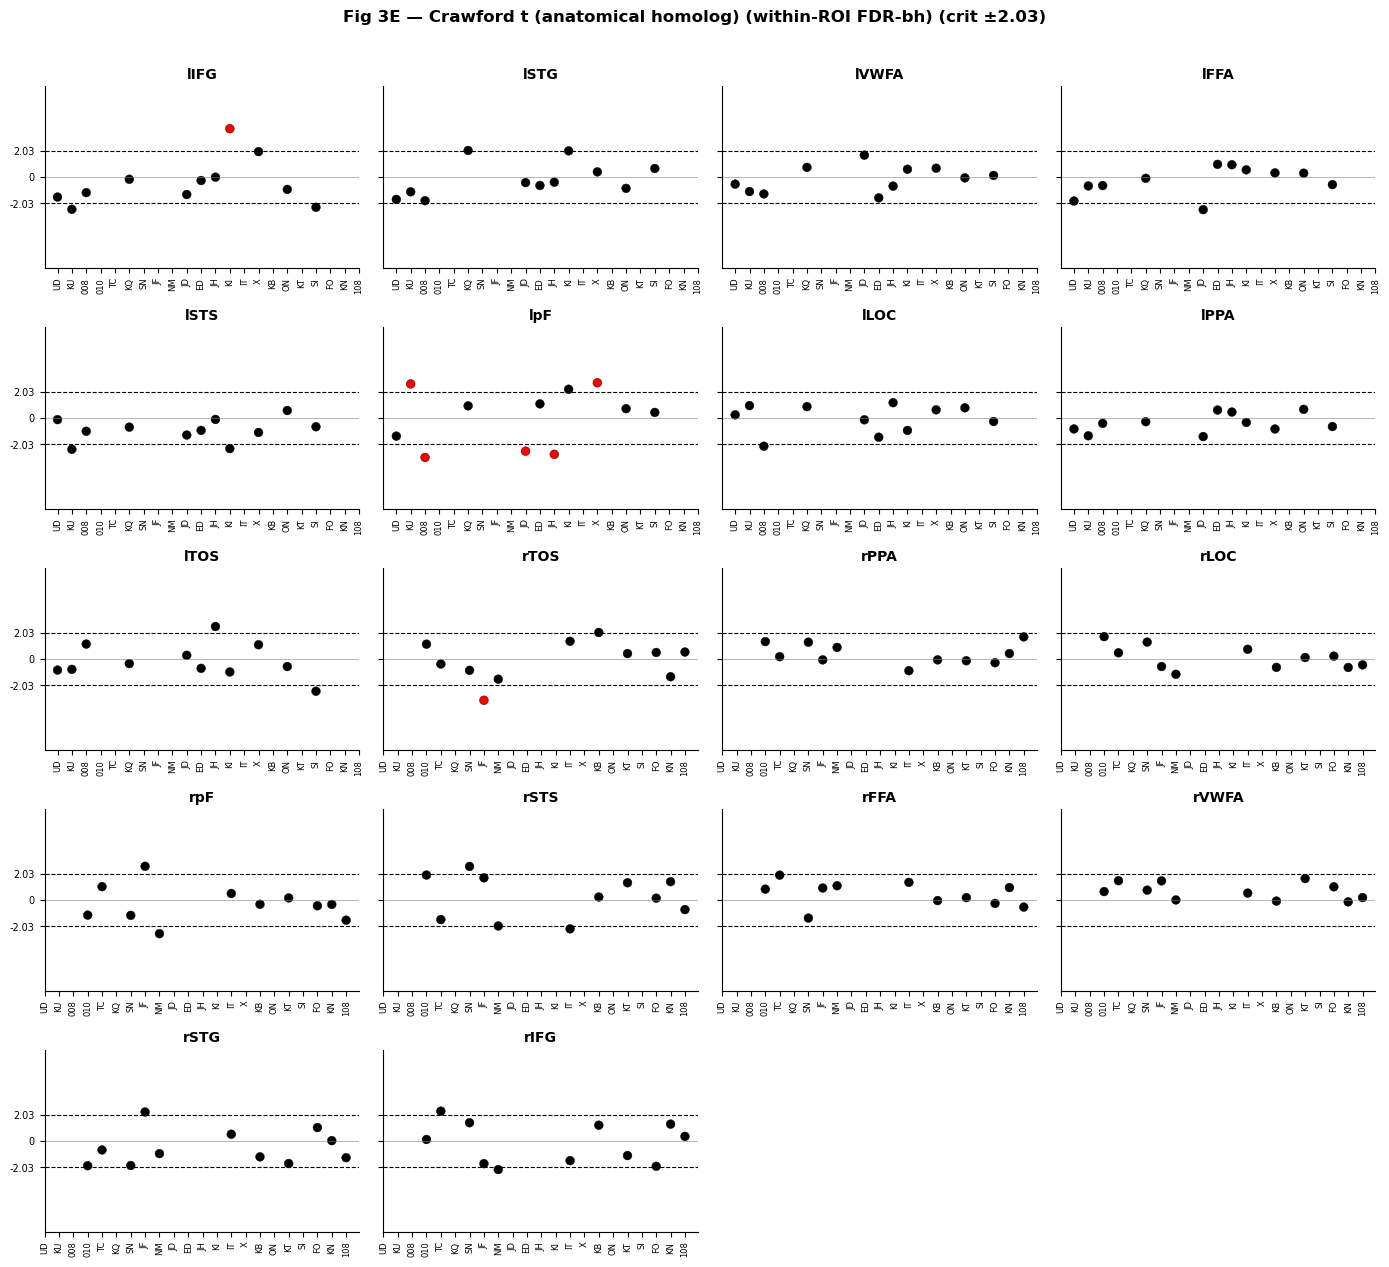

In [29]:
t_mat = np.full((n, len(otc_subs)), np.nan)
p_mat = np.full((n, len(otc_subs)), np.nan)
n_ctrls_roi = np.zeros(n, dtype=int)

for r, (roi, hspec) in enumerate(ROI_ORDER):
    cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == hspec)]['liu_distinctiveness'].dropna().values
    n_ctrls_roi[r] = len(cvals)
    if len(cvals) < 3: continue
    for p_, sub in enumerate(otc_subs):
        pt_h = pt_intact_hemi(sub)
        if pt_h is None or pt_h != hspec: continue
        val = get_distinct(pt_le, sub, roi, hspec)
        if np.isnan(val): continue
        t_mat[r, p_], p_mat[r, p_] = crawford(val, cvals)

min_df = max(int(n_ctrls_roi[n_ctrls_roi > 0].min()) - 1, 1)
crit_3E = float(tdist.ppf(0.975, df=min_df))

# FDR scoped WITHIN each ROI (across patients), not globally.
sig_mat = np.abs(t_mat) > crit_3E
if FDR_METHOD is not None:
    sig_mat = np.zeros_like(t_mat, dtype=bool)
    for r in range(n):
        sig_mat[r, :] = fdr_correct(p_mat[r, :], method=FDR_METHOD)
    n_raw = int((np.abs(t_mat) > crit_3E).sum())
    n_fdr = int(sig_mat.sum())
    print(f'Significant (raw α=.05):     {n_raw} / {(~np.isnan(t_mat)).sum()}')
    print(f'Significant (within-ROI FDR-{FDR_METHOD}): {n_fdr} / {(~np.isnan(t_mat)).sum()}')
else:
    print(f'Significant (uncorrected): {int(sig_mat.sum())} / {(~np.isnan(t_mat)).sum()}')

print(f'n_ctrl per ROI: min={n_ctrls_roi[n_ctrls_roi>0].min()}, max={n_ctrls_roi.max()}')
print(f'Critical t (uncorrected, df={min_df}): ±{crit_3E:.3f}\n')

n_cols_3E = 4
n_rows_3E = int(np.ceil(n / n_cols_3E))
fig, axes = plt.subplots(n_rows_3E, n_cols_3E, figsize=(3.5 * n_cols_3E, 2.5 * n_rows_3E), sharey=True)
axes = axes.flatten()
pt_labels = [SUB_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
for r, (roi, hspec) in enumerate(ROI_ORDER):
    ax = axes[r]
    xs = np.arange(len(otc_subs))
    tv = t_mat[r]
    colors = ['red' if sig_mat[r, i] else 'black' for i in range(len(otc_subs))]
    ax.scatter(xs, tv, s=40, c=colors, edgecolors='k', linewidth=0.3)
    ax.axhline( crit_3E, color='k', lw=0.8, ls='--')
    ax.axhline(-crit_3E, color='k', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-7, 7); ax.set_yticks([-crit_3E, 0, crit_3E])
    ax.set_yticklabels([f'{-crit_3E:.2f}', '0', f'{crit_3E:.2f}'], fontsize=7)
    ax.set_xticks(xs); ax.set_xticklabels(pt_labels, rotation=90, fontsize=6)
    ax.set_title(roi_label(roi, hspec), fontsize=10, fontweight='bold')
for r in range(n, len(axes)):
    axes[r].axis('off')
suffix = f' (within-ROI FDR-{FDR_METHOD})' if FDR_METHOD else ' (uncorrected)'
plt.suptitle(f'Fig 3E — Crawford t (anatomical homolog){suffix} (crit ±{crit_3E:.2f})',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig3E.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Fig 3E′ — Per-category-pair Crawford *t* (with FDR)

Preferred vs each non-preferred category, per ROI × patient. 3 t-values per cell.

Significant (raw):       58 / 594
Significant (FDR-bh):  7 / 594


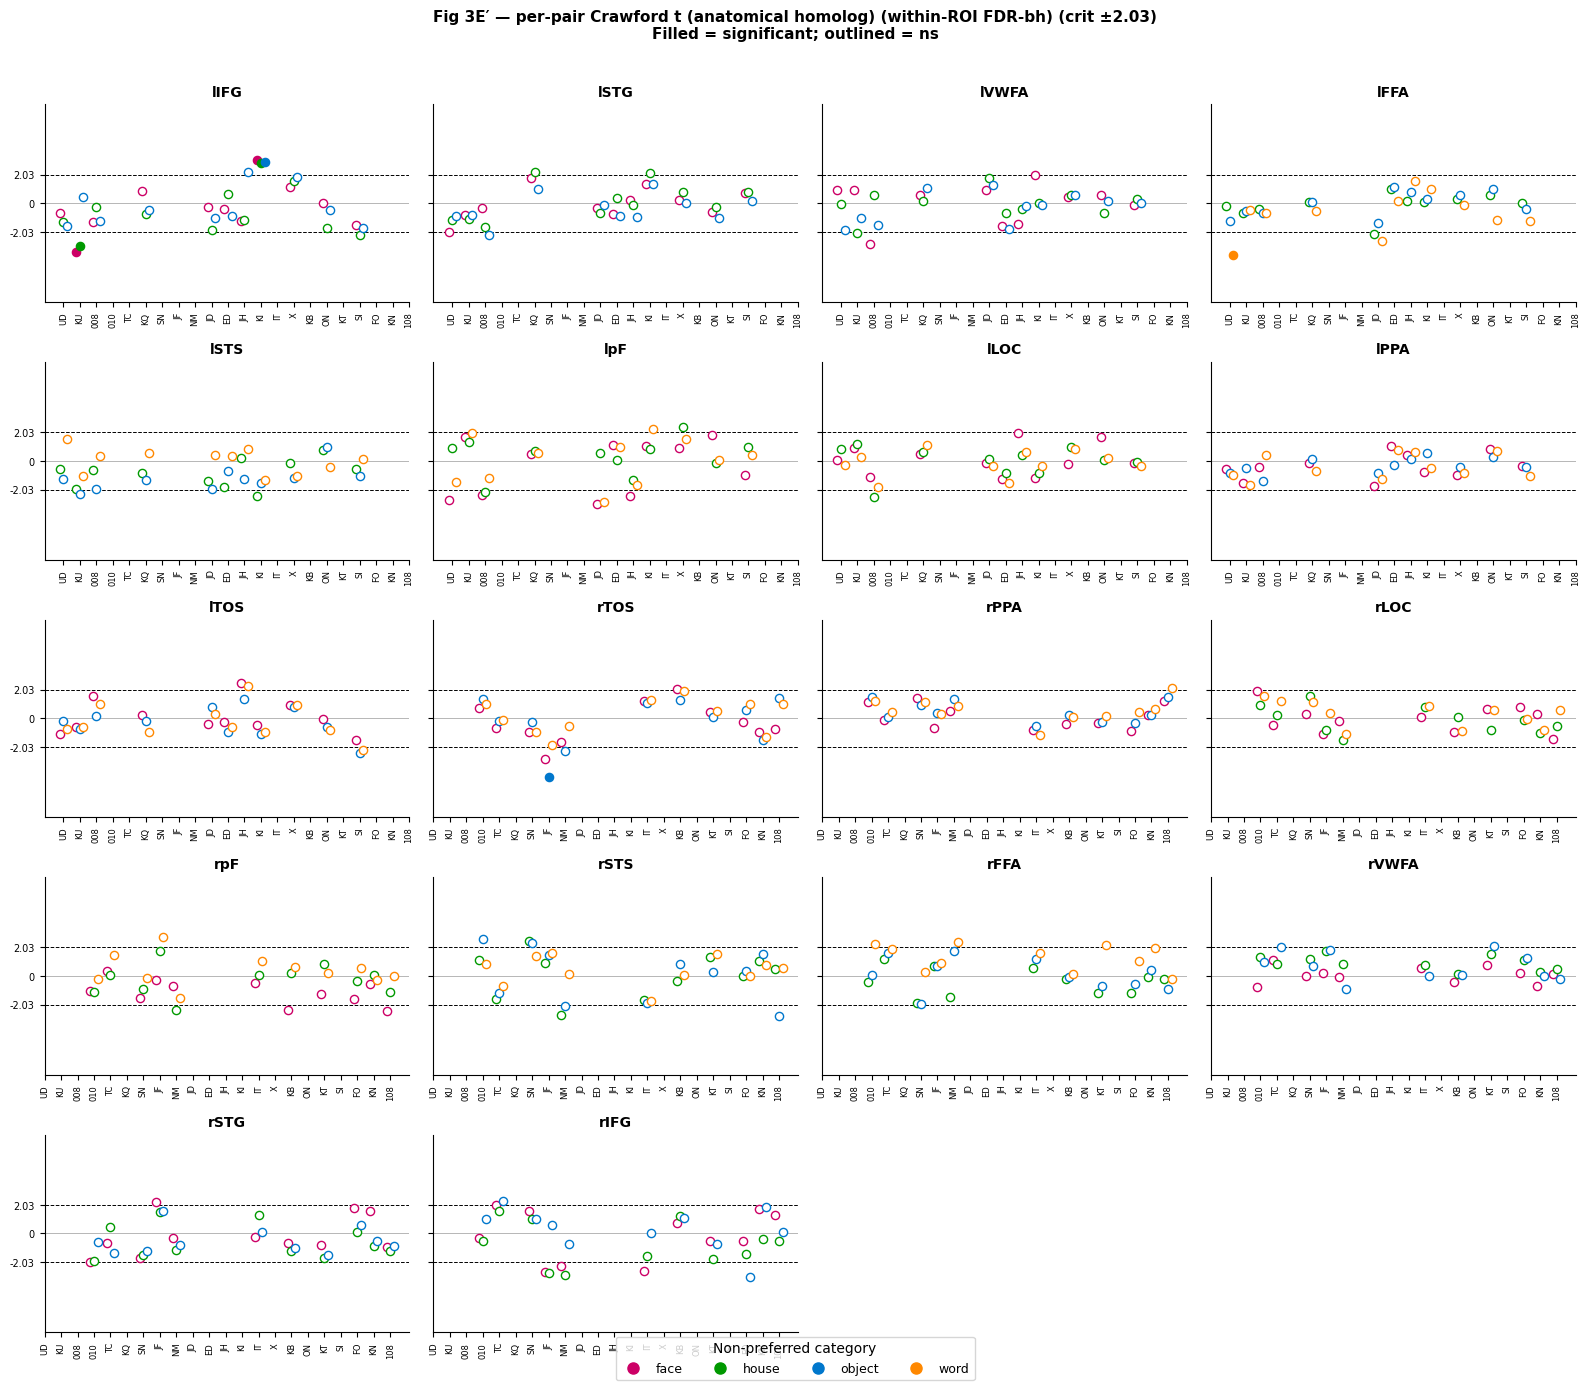

In [30]:
PARENT = {'face_FFA': 'face', 'face_STS': 'face',
          'house_PPA': 'house', 'house_TOS': 'house',
          'object_pF': 'object', 'object_LOC': 'object',
          'word_VWFA': 'word', 'word_STG': 'word', 'word_pSTG_liu': 'word',
          'word_IFG': 'word'}
CAT_COLOR = {'face': '#cc0066', 'house': '#009900', 'object': '#0077cc', 'word': '#ff8800'}

def get_pair_fz(df, sub, cat, hemi, pair_str):
    a, b = pair_str.split('-')
    m = df[(df['subject_id'] == sub) & (df['category'] == cat) & (df['hemi'] == hemi) &
           (df['pair'].isin([f'{a}-{b}', f'{b}-{a}']))]
    return m['fisher_r'].iloc[0] if len(m) else np.nan

NONPREF_CATS = {roi: [c for c in ['face', 'house', 'object', 'word'] if c != PARENT[roi]]
                for roi, _ in ROI_ORDER}

t_pair = np.full((n, len(otc_subs), 3), np.nan)
p_pair = np.full((n, len(otc_subs), 3), np.nan)
n_ctrl_pair = np.zeros((n, 3), dtype=int)

for r, (roi, hspec) in enumerate(ROI_ORDER):
    pref = PARENT[roi]
    for k, nonpref in enumerate(NONPREF_CATS[roi]):
        pair_str = f'{pref}-{nonpref}'
        cvals = np.array([get_pair_fz(ctrl_pw, s, roi, hspec, pair_str) for s in ctrl_subs])
        cvals = cvals[~np.isnan(cvals)]
        n_ctrl_pair[r, k] = len(cvals)
        if len(cvals) < 3: continue
        for p, sub in enumerate(otc_subs):
            pt_h = pt_intact_hemi(sub)
            if pt_h is None or pt_h != hspec: continue
            x = get_pair_fz(pt_pw, sub, roi, hspec, pair_str)
            if np.isnan(x): continue
            t_pair[r, p, k], p_pair[r, p, k] = crawford(x, cvals)

min_df_3E = max(int(n_ctrl_pair[n_ctrl_pair > 0].min()) - 1, 1)
crit_3Ep = float(tdist.ppf(0.975, df=min_df_3E))

sig_pair = np.abs(t_pair) > crit_3Ep
if FDR_METHOD is not None:
    sig_pair = np.zeros_like(t_pair, dtype=bool)
    for r in range(n):
        roi_p = p_pair[r, :, :].flatten()
        sig_pair[r, :, :] = fdr_correct(roi_p, method=FDR_METHOD).reshape(p_pair[r].shape)
    print(f'Significant (raw):       {int((np.abs(t_pair) > crit_3Ep).sum())} / {(~np.isnan(t_pair)).sum()}')
    print(f'Significant (FDR-{FDR_METHOD}):  {int(sig_pair.sum())} / {(~np.isnan(t_pair)).sum()}')

n_cols_pair = 4
n_rows_pair = int(np.ceil(n / n_cols_pair))
fig, axes = plt.subplots(n_rows_pair, n_cols_pair, figsize=(4 * n_cols_pair, 2.7 * n_rows_pair), sharey=True)
axes = axes.flatten()
pt_labels = [SUB_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
offsets_3k = [-0.22, 0, 0.22]

for r, (roi, hspec) in enumerate(ROI_ORDER):
    ax = axes[r]
    xs_base = np.arange(len(otc_subs))
    for k, nonpref in enumerate(NONPREF_CATS[roi]):
        xs = xs_base + offsets_3k[k]
        for i in range(len(otc_subs)):
            tv = t_pair[r, i, k]
            if np.isnan(tv): continue
            is_sig = sig_pair[r, i, k]
            ax.scatter(xs[i], tv, s=35,
                       facecolors=CAT_COLOR[nonpref] if is_sig else 'white',
                       edgecolors=CAT_COLOR[nonpref], linewidth=1.0, zorder=3)
    ax.axhline( crit_3Ep, color='k', lw=0.7, ls='--')
    ax.axhline(-crit_3Ep, color='k', lw=0.7, ls='--')
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-7, 7)
    ax.set_yticks([-crit_3Ep, 0, crit_3Ep])
    ax.set_yticklabels([f'{-crit_3Ep:.2f}', '0', f'{crit_3Ep:.2f}'], fontsize=7)
    ax.set_xticks(xs_base); ax.set_xticklabels(pt_labels, rotation=90, fontsize=6)
    ax.set_title(roi_label(roi, hspec), fontsize=10, fontweight='bold')

for r in range(n, len(axes)):
    axes[r].axis('off')

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor=c, markersize=8, label=cat)
                  for cat, c in CAT_COLOR.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.01), title='Non-preferred category')

suffix = f' (within-ROI FDR-{FDR_METHOD})' if FDR_METHOD else ' (uncorrected)'
plt.suptitle(f'Fig 3E\u2032 — per-pair Crawford t (anatomical homolog){suffix} (crit \u00b1{crit_3Ep:.2f})\n'
             f'Filled = significant; outlined = ns',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig3E_pairs.png', dpi=300, bbox_inches='tight')
plt.show()


## 10. Sum-selectivity (Ayzenberg 2023)

Bootstrapped 95% CI of control mean (10,000 resamples with replacement).
Patient value flagged if outside CI.

  face LH: n_pt=11, n_ct=38, t=-0.34, p=0.739, d=-0.15
  face RH: n_pt=11, n_ct=38, t=-0.13, p=0.898, d=-0.04
  house LH: n_pt=11, n_ct=38, t=-0.27, p=0.789, d=-0.10
  house RH: n_pt=11, n_ct=38, t=-1.37, p=0.194, d=-0.55
  object LH: n_pt=11, n_ct=38, t=-1.98, p=0.073, d=-1.08
  object RH: n_pt=11, n_ct=38, t=-1.44, p=0.174, d=-0.63
  word LH: n_pt=10, n_ct=36, t=-1.02, p=0.322, d=-0.31
  word RH: n_pt=10, n_ct=38, t=+1.67, p=0.107, d=+0.45


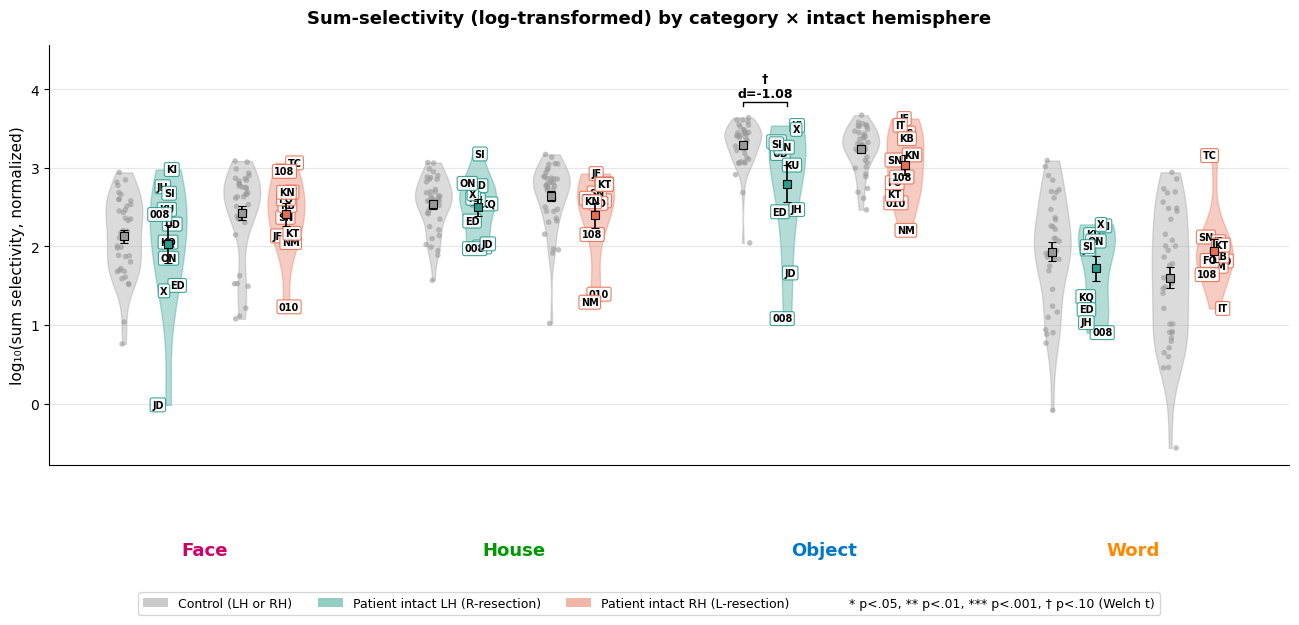

In [31]:
from scipy import stats

CAT_SUBROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu'],
}
CAT_COLORS_SS = {'face': '#cc0066', 'house': '#009900',
                 'object': '#0077cc', 'word': '#ff8800'}

CTRL_L_COLOR = '#999999'
CTRL_R_COLOR = '#999999'
PT_L_COLOR   = '#2a9d8f'
PT_R_COLOR   = '#e76f51'

def collapse_log_selec(df, subject, category, hemi):
    vals = df[(df['subject_id'] == subject) &
              (df['category'].isin(CAT_SUBROIS[category])) &
              (df['hemi'] == hemi)]['sum_selec_norm'].dropna().values
    vals = vals[vals > 0]
    return np.mean(np.log10(vals)) if len(vals) else np.nan

def short_name(sub):
    return SUB_CODES.get(sub, sub.replace('sub-', ''))

def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    pooled = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled

def build_table(df, subjects):
    rows = []
    for s in subjects:
        for cat in CAT_SUBROIS:
            for h in ('l', 'r'):
                v = collapse_log_selec(df, s, cat, h)
                if not np.isnan(v):
                    rows.append({'subject_id': s, 'category': cat, 'hemi': h, 'val': v})
    return pd.DataFrame(rows)

ctrl_selec = build_table(ctrl_le, ctrl_subs)
pt_selec   = build_table(pt_le,   otc_subs)

intact_lookup = dict(zip(pt_le['subject_id'], pt_le['intact_hemi']))
pt_selec['intact_hemi'] = pt_selec['subject_id'].map(intact_lookup)
pt_selec = pt_selec[
    ((pt_selec['intact_hemi'] == 'left')  & (pt_selec['hemi'] == 'l')) |
    ((pt_selec['intact_hemi'] == 'right') & (pt_selec['hemi'] == 'r'))
]

CATS_PANEL = ['face', 'house', 'object', 'word']

INTRA   = 0.6
INTER   = 1.0
CAT_GAP = 2.0
positions_within = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]
cat_width = positions_within[-1]

fig, ax = plt.subplots(figsize=(16, 6))
RNG_SS = np.random.RandomState(42)

all_ticks, all_labels, cat_centers = [], [], []

for ci, cat in enumerate(CATS_PANEL):
    base = ci * (cat_width + CAT_GAP)
    positions = [base + p for p in positions_within]
    cat_centers.append(np.mean(positions))

    cl = ctrl_selec[(ctrl_selec['category'] == cat) & (ctrl_selec['hemi'] == 'l')]['val'].values
    cr = ctrl_selec[(ctrl_selec['category'] == cat) & (ctrl_selec['hemi'] == 'r')]['val'].values
    pl = pt_selec[(pt_selec['category'] == cat)   & (pt_selec['hemi']   == 'l')]
    pr = pt_selec[(pt_selec['category'] == cat)   & (pt_selec['hemi']   == 'r')]

    groups = [
        (cl,                 positions[0], CTRL_L_COLOR, 'violin', None),
        (pl['val'].values,   positions[1], PT_L_COLOR,   'labels', pl['subject_id'].values),
        (cr,                 positions[2], CTRL_R_COLOR, 'violin', None),
        (pr['val'].values,   positions[3], PT_R_COLOR,   'labels', pr['subject_id'].values),
    ]

    for vals, pos, col, kind, subs in groups:
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0: continue
        if len(vals) >= 2:
            parts = ax.violinplot([vals], positions=[pos], widths=0.5,
                                  showmeans=False, showmedians=False, showextrema=False)
            for b in parts['bodies']:
                b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor(col)
        if kind == 'violin':
            jit = RNG_SS.uniform(-0.1, 0.1, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=col, alpha=0.6, s=16, edgecolors='none', zorder=3)
        else:
            for v, sub in zip(vals, subs):
                jit = RNG_SS.uniform(-0.15, 0.15)
                ax.annotate(short_name(sub), (pos + jit, v),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=col, alpha=0.9, linewidth=0.8),
                            zorder=4)
        ax.errorbar(pos, np.mean(vals),
                    yerr=np.std(vals)/np.sqrt(max(len(vals), 1)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=col, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

# Group-level significance: Welch t + Cohen\'s d
    for pos_ctrl, pos_pt, pt_vals, ctrl_vals in [
        (positions[0], positions[1], pl['val'].values, cl),
        (positions[2], positions[3], pr['val'].values, cr),
    ]:
        pt_vals = pt_vals[~np.isnan(pt_vals)]
        ctrl_vals = ctrl_vals[~np.isnan(ctrl_vals)]
        if len(pt_vals) < 2 or len(ctrl_vals) < 3: continue
        t, p = stats.ttest_ind(pt_vals, ctrl_vals, equal_var=False)
        d = cohens_d(pt_vals, ctrl_vals)
        hemi_label = 'LH' if pos_pt == positions[1] else 'RH'
        print(f'  {cat} {hemi_label}: n_pt={len(pt_vals)}, n_ct={len(ctrl_vals)}, '
              f't={t:+.2f}, p={p:.3f}, d={d:+.2f}')
        if p < 0.05:
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        elif p < 0.10:
            sig = '\u2020'
        else:
            continue
        y_top = max(np.max(pt_vals), np.max(ctrl_vals))
        y_br = y_top + 0.15
        ax.plot([pos_ctrl, pos_ctrl, pos_pt, pos_pt],
                [y_br, y_br + 0.05, y_br + 0.05, y_br],
                color='black', linewidth=1, clip_on=False)
        ax.text((pos_ctrl + pos_pt) / 2, y_br + 0.07,
                f'{sig}\nd={d:+.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(all_ticks)
ax.set_xticklabels(all_labels, fontsize=8)
ax.set_ylabel('log\u2081\u2080(sum selectivity, normalized)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for cat, center in zip(CATS_PANEL, cat_centers):
    ax.text(center, -0.18, cat.title(), fontsize=13, fontweight='bold',
            color=CAT_COLORS_SS[cat], ha='center', va='top',
            transform=ax.get_xaxis_transform())

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax + 0.5)

legend_elements = [
    Patch(facecolor=CTRL_L_COLOR, alpha=0.5, label='Control (LH or RH)'),
    Patch(facecolor=PT_L_COLOR,   alpha=0.5, label='Patient intact LH (R-resection)'),
    Patch(facecolor=PT_R_COLOR,   alpha=0.5, label='Patient intact RH (L-resection)'),
    Line2D([0], [0], marker='None', linestyle='None',
           label='* p<.05, ** p<.01, *** p<.001, \u2020 p<.10 (Welch t)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Sum-selectivity (log-transformed) by category \u00d7 intact hemisphere',
             fontsize=13, fontweight='bold', y=0.98)
plt.subplots_adjust(bottom=0.22, top=0.92)
plt.savefig(FIG_DIR / 'liu_exact_sum_selectivity.png', dpi=300, bbox_inches='tight')
plt.show()


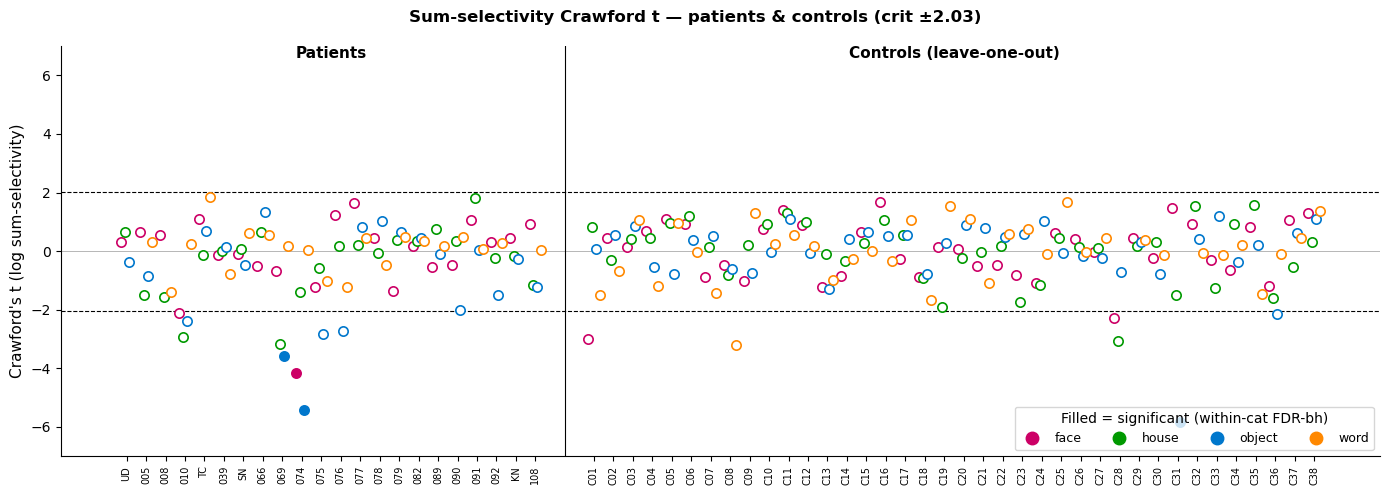

In [32]:
CAT_SUBROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu'],
}
CATS_PANEL = ['face', 'house', 'object', 'word']
CAT_COLORS_SS = {'face': '#cc0066', 'house': '#009900',
                 'object': '#0077cc', 'word': '#ff8800'}

def get_sel(df, sub, cat, hemi):
    vals = df[(df['subject_id']==sub) & (df['category'].isin(CAT_SUBROIS[cat])) &
              (df['hemi']==hemi)]['sum_selec_norm'].dropna().values
    vals = vals[vals > 0]
    return np.mean(np.log10(vals)) if len(vals) else np.nan

N_PT = len(otc_subs)
N_CT = len(ctrl_subs)

# Patient Crawford t at intact hemi
t_pt_flat = {cat: np.full(N_PT, np.nan) for cat in CATS_PANEL}
p_pt_flat = {cat: np.full(N_PT, np.nan) for cat in CATS_PANEL}
for cat in CATS_PANEL:
    for pi, sub in enumerate(otc_subs):
        pt_h = pt_intact_hemi(sub)
        if pt_h is None: continue
        cvals = np.array([get_sel(ctrl_le, s, cat, pt_h) for s in ctrl_subs])
        cvals = cvals[~np.isnan(cvals)]
        if len(cvals) < 3: continue
        x = get_sel(pt_le, sub, cat, pt_h)
        if np.isnan(x): continue
        t_pt_flat[cat][pi], p_pt_flat[cat][pi] = crawford(x, cvals)

# Control leave-one-out at LH
t_ctrl_sel = {cat: np.full(N_CT, np.nan) for cat in CATS_PANEL}
p_ctrl_sel = {cat: np.full(N_CT, np.nan) for cat in CATS_PANEL}
for cat in CATS_PANEL:
    cvals_all = np.array([get_sel(ctrl_le, s, cat, 'l') for s in ctrl_subs])
    for ci in range(N_CT):
        if np.isnan(cvals_all[ci]): continue
        others = np.delete(cvals_all, ci)
        others = others[~np.isnan(others)]
        if len(others) < 3: continue
        t_ctrl_sel[cat][ci], p_ctrl_sel[cat][ci] = crawford(cvals_all[ci], others)

min_df_sel = N_CT - 1
crit_sel = float(tdist.ppf(0.975, df=min_df_sel))

# Within-cat FDR across patients + controls
sig_pt_flat   = {cat: np.zeros(N_PT, bool) for cat in CATS_PANEL}
sig_ctrl_flat = {cat: np.zeros(N_CT, bool) for cat in CATS_PANEL}
if FDR_METHOD is not None:
    for cat in CATS_PANEL:
        all_p = np.concatenate([p_pt_flat[cat], p_ctrl_sel[cat]])
        all_sig = fdr_correct(all_p, method=FDR_METHOD)
        sig_pt_flat[cat]   = all_sig[:N_PT]
        sig_ctrl_flat[cat] = all_sig[N_PT:]
else:
    for cat in CATS_PANEL:
        sig_pt_flat[cat]   = np.abs(t_pt_flat[cat])  > crit_sel
        sig_ctrl_flat[cat] = np.abs(t_ctrl_sel[cat]) > crit_sel

fig, ax = plt.subplots(figsize=(14, 5))
CAT_OFFSETS = {'face': -0.3, 'house': -0.1, 'object': 0.1, 'word': 0.3}
PT_XS = np.arange(N_PT)
CT_XS = np.arange(N_CT) + N_PT + 2

pt_labels = [LIU_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
ctrl_labels = [f'C{i+1:02d}' for i in range(N_CT)]

for cat in CATS_PANEL:
    color = CAT_COLORS_SS[cat]
    off = CAT_OFFSETS[cat]
    for pi in range(N_PT):
        tv = t_pt_flat[cat][pi]
        if np.isnan(tv): continue
        is_sig = sig_pt_flat[cat][pi]
        ax.scatter(PT_XS[pi] + off, tv, s=45,
                   facecolors=color if is_sig else 'white',
                   edgecolors=color, linewidth=1.2, zorder=3)
    for ci in range(N_CT):
        tv = t_ctrl_sel[cat][ci]
        if np.isnan(tv): continue
        is_sig = sig_ctrl_flat[cat][ci]
        ax.scatter(CT_XS[ci] + off, tv, s=45,
                   facecolors=color if is_sig else 'white',
                   edgecolors=color, linewidth=1.2, zorder=3)

ax.axhline( crit_sel, color='k', lw=0.8, ls='--')
ax.axhline(-crit_sel, color='k', lw=0.8, ls='--')
ax.axhline(0, color='gray', lw=0.4)
ax.axvline(N_PT + 0.5, color='k', lw=0.8)
ax.set_ylim(-7, 7)

ax.set_xticks(list(PT_XS) + list(CT_XS))
ax.set_xticklabels(pt_labels + ctrl_labels, rotation=90, fontsize=7)
ax.set_ylabel("Crawford's t (log sum-selectivity)", fontsize=11)

ax.text(np.mean(PT_XS), 6.6, 'Patients',
        ha='center', fontsize=11, fontweight='bold')
ax.text(np.mean(CT_XS), 6.6, 'Controls (leave-one-out)',
        ha='center', fontsize=11, fontweight='bold')

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor=c, markersize=9, label=cat)
                  for cat, c in CAT_COLORS_SS.items()]
suffix = f' (within-cat FDR-{FDR_METHOD})' if FDR_METHOD else ' (uncorrected)'
ax.legend(handles=legend_handles, loc='lower right', ncol=4, fontsize=9,
          title=f'Filled = significant{suffix}')

plt.suptitle(f"Sum-selectivity Crawford t — patients & controls (crit ±{crit_sel:.2f})",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_sum_selec_crawford.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Validation summary

In [33]:
print('=== Sphere voxel counts (expect ~175 at 2mm) ===')
summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates()
print(summary.groupby('category')['n_sphere_voxels'].agg(['mean', 'min', 'max']).round(0))

print('\n=== TC (sub-021) word ROIs at intact RH vs control RH distribution ===')
for roi in ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG']:
    tc = pt_le[(pt_le['subject_id'] == 'sub-021') & (pt_le['category'] == roi) &
               (pt_le['hemi'] == 'r')]['liu_distinctiveness'].values
    cv = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == 'r')]['liu_distinctiveness'].dropna().values
    if len(tc) and len(cv):
        t, p = crawford(tc[0], cv)
        print(f'  {roi:15s}: TC={tc[0]:.3f}, ctrl M={cv.mean():.3f} (SD={cv.std():.3f}), '
              f't={t:+.2f}, p={p:.3f}')

print('\n=== ROI × hemi coverage ===')
print(le_summary.groupby(['category', 'hemi'])['subject_id'].nunique().unstack(fill_value=0))

=== Sphere voxel counts (expect ~175 at 2mm) ===
                mean  min  max
category                      
evc            166.0  134  192
face_FFA       168.0  148  192
face_STS       173.0  148  192
house_PPA      170.0  142  192
house_TOS      172.0  148  192
object_LOC     170.0  148  192
object_pF      168.0  148  192
word_IFG       170.0  148  192
word_STG       170.0  138  192
word_VWFA      171.0  148  192
word_pSTG_liu  174.0  148  192

=== TC (sub-021) word ROIs at intact RH vs control RH distribution ===
  word_VWFA      : TC=1.148, ctrl M=0.365 (SD=0.514), t=+1.48, p=0.147
  word_STG       : TC=0.312, ctrl M=0.579 (SD=0.372), t=-0.70, p=0.489
  word_pSTG_liu  : TC=1.011, ctrl M=0.587 (SD=0.376), t=+1.10, p=0.279
  word_IFG       : TC=1.815, ctrl M=0.817 (SD=0.424), t=+2.30, p=0.027

=== ROI × hemi coverage ===
hemi            l   r
category             
evc            54  53
face_FFA       54  53
face_STS       54  53
house_PPA      54  53
house_TOS      54  53
object_LO

In [34]:
# Sum-selectivity (log): L-res = intact RH, R-res = intact LH
l_res_obj = pt_selec[(pt_selec['category']=='object') & (pt_selec['intact_hemi']=='right')]['val']
r_res_obj = pt_selec[(pt_selec['category']=='object') & (pt_selec['intact_hemi']=='left')]['val']
ctrl_lh = ctrl_selec[(ctrl_selec['category']=='object') & (ctrl_selec['hemi']=='l')]['val']
ctrl_rh = ctrl_selec[(ctrl_selec['category']=='object') & (ctrl_selec['hemi']=='r')]['val']

print(f'L-res obj (intact RH): n={len(l_res_obj)}, mean={l_res_obj.mean():.2f}, vs ctrl RH mean={ctrl_rh.mean():.2f}')
print(f'R-res obj (intact LH): n={len(r_res_obj)}, mean={r_res_obj.mean():.2f}, vs ctrl LH mean={ctrl_lh.mean():.2f}')

# Representation: distinctiveness at intact hemi for object ROIs
for roi in ['object_pF', 'object_LOC']:
    for side, intact_h in [('L-res', 'r'), ('R-res', 'l')]:
        pt_d = pt_le[(pt_le['category']==roi) & (pt_le['hemi']==intact_h)]['liu_distinctiveness']
        ct_d = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==intact_h)]['liu_distinctiveness']
        print(f'{roi} {side}: pt mean={pt_d.mean():.2f} (n={len(pt_d)}), ctrl mean={ct_d.mean():.2f}')

L-res obj (intact RH): n=11, mean=3.03, vs ctrl RH mean=3.24
R-res obj (intact LH): n=11, mean=2.80, vs ctrl LH mean=3.29
object_pF L-res: pt mean=0.81 (n=11), ctrl mean=0.91
object_pF R-res: pt mean=0.89 (n=11), ctrl mean=0.87
object_LOC L-res: pt mean=1.28 (n=11), ctrl mean=1.23
object_LOC R-res: pt mean=1.03 (n=11), ctrl mean=1.05


In [35]:
import pandas as pd
import numpy as np

# Build full summary: category × hemi × group
CATEGORIES = ['face', 'house', 'object', 'word']
HEMIS = ['l', 'r']

def mean_sum_selec(df, subs, cat, hemi):
    vals = []
    for s in subs:
        v = collapse_log_selec(df, s, cat, hemi)
        if not np.isnan(v): vals.append(v)
    return np.array(vals)

def mean_distinct(df, subs, cat_roi, hemi):
    return df[(df['subject_id'].isin(subs)) & (df['category']==cat_roi) &
              (df['hemi']==hemi)]['liu_distinctiveness'].dropna().values

def mean_peakx(df, subs, cat_roi, hemi):
    return df[(df['subject_id'].isin(subs)) & (df['category']==cat_roi) &
              (df['hemi']==hemi)]['peak_x_native'].dropna().values

# Group definitions
lh_pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == 'l']  # R-res
rh_pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == 'r']  # L-res

PRIMARY_ROI = {'face': 'face_FFA', 'house': 'house_PPA',
               'object': 'object_pF', 'word': 'word_VWFA'}

rows = []
for cat in CATEGORIES:
    for hemi in HEMIS:
        roi = PRIMARY_ROI[cat]
        # Groups per hemi (patients only contribute if intact hemi matches)
        ctrl_ss   = mean_sum_selec(ctrl_le, ctrl_subs, cat, hemi)
        pt_subs_h = lh_pt_subs if hemi == 'l' else rh_pt_subs
        pt_ss     = mean_sum_selec(pt_le, pt_subs_h, cat, hemi)
        ctrl_d = mean_distinct(ctrl_le, ctrl_subs, roi, hemi)
        pt_d   = mean_distinct(pt_le, pt_subs_h, roi, hemi)
        ctrl_x = mean_peakx(ctrl_le, ctrl_subs, roi, hemi)
        pt_x   = mean_peakx(pt_le, pt_subs_h, roi, hemi)

        rows.append({
            'category': cat, 'hemi': hemi,
            'n_pt': len(pt_ss), 'n_ctrl': len(ctrl_ss),
            'ss_pt': pt_ss.mean() if len(pt_ss) else np.nan,
            'ss_ctrl': ctrl_ss.mean() if len(ctrl_ss) else np.nan,
            'ss_d': cohens_d(pt_ss, ctrl_ss) if len(pt_ss)>=2 and len(ctrl_ss)>=3 else np.nan,
            'dist_pt': pt_d.mean() if len(pt_d) else np.nan,
            'dist_ctrl': ctrl_d.mean() if len(ctrl_d) else np.nan,
            'dist_d': cohens_d(pt_d, ctrl_d) if len(pt_d)>=2 and len(ctrl_d)>=3 else np.nan,
            'peakx_pt': pt_x.mean() if len(pt_x) else np.nan,
            'peakx_ctrl': ctrl_x.mean() if len(ctrl_x) else np.nan,
            'peakx_d': cohens_d(pt_x, ctrl_x) if len(pt_x)>=2 and len(ctrl_x)>=3 else np.nan,
        })

df_summary = pd.DataFrame(rows)
print(df_summary.round(2).to_string(index=False))

category hemi  n_pt  n_ctrl  ss_pt  ss_ctrl  ss_d  dist_pt  dist_ctrl  dist_d  peakx_pt  peakx_ctrl  peakx_d
    face    l    11      38   2.04     2.13 -0.15     0.57       0.67   -0.30    -37.00      -35.88    -0.25
    face    r    11      38   2.41     2.43 -0.04     0.72       0.55    0.46     35.17       38.50    -0.68
   house    l    11      38   2.50     2.53 -0.10     0.12       0.44   -0.44    -13.79      -17.50     0.41
   house    r    11      38   2.39     2.64 -0.55     0.83       0.50    0.41     17.32       20.68    -0.40
  object    l    11      38   2.80     3.29 -1.08     0.89       0.87    0.06    -29.32      -34.89     1.06
  object    r    11      38   3.03     3.24 -0.63     0.81       0.91   -0.28     32.15       34.96    -0.51
    word    l    10      36   1.72     1.93 -0.31     0.57       0.64   -0.15    -24.49      -27.51     0.51
    word    r    10      38   1.95     1.60  0.45     0.72       0.36    0.74     26.82       28.97    -0.39


In [36]:
# Patient covariates (from info sheet, last session)
PT_INFO = {
    'sub-004': {'age_scan': 13.08, 'age_surgery': 6,    'age_seizure': 4},
    'sub-005': {'age_scan': 19.42, 'age_surgery': 6,    'age_seizure': 6},
    'sub-008': {'age_scan': 17.90, 'age_surgery': 8,    'age_seizure': 0},
    'sub-010': {'age_scan': 14.30, 'age_surgery': 5,    'age_seizure': 4},
    'sub-021': {'age_scan': 15.80, 'age_surgery': 13,   'age_seizure': 6},
    'sub-039': {'age_scan': 17.02, 'age_surgery': 15,   'age_seizure': 13},
    'sub-044': {'age_scan': 12.48, 'age_surgery': 0,    'age_seizure': 0},
    'sub-066': {'age_scan': 16.81, 'age_surgery': 4,    'age_seizure': 0},
    'sub-069': {'age_scan': 12.16, 'age_surgery': 0,    'age_seizure': 0},
    'sub-074': {'age_scan': 13.05, 'age_surgery': 13,   'age_seizure': 10},
    'sub-075': {'age_scan': 11.58, 'age_surgery': 4,    'age_seizure': 6},
    'sub-076': {'age_scan': 16.07, 'age_surgery': 10,   'age_seizure': 0},
    'sub-077': {'age_scan': 7.80,  'age_surgery': 3,    'age_seizure': 2},
    'sub-078': {'age_scan': 22.22, 'age_surgery': 17,   'age_seizure': 11},
    'sub-079': {'age_scan': 17.34, 'age_surgery': 16,   'age_seizure': 11},
    'sub-082': {'age_scan': 20.46, 'age_surgery': 18,   'age_seizure': 13},
    'sub-089': {'age_scan': 18.29, 'age_surgery': 12,   'age_seizure': 7},
    'sub-091': {'age_scan': 37.26, 'age_surgery': 27,   'age_seizure': 10},
    'sub-092': {'age_scan': 19.78, 'age_surgery': 4,    'age_seizure': 1},
    'sub-099': {'age_scan': 11.54, 'age_surgery': 1.7,  'age_seizure': 0.6},
    'sub-108': {'age_scan': 18.00, 'age_surgery': 6,    'age_seizure': 0},
}

def get_distinct(df, sub, roi, hemi):
    m = df[(df['subject_id']==sub) & (df['category']==roi) & (df['hemi']==hemi)]
    return m['liu_distinctiveness'].iloc[0] if len(m) else np.nan

def get_peakx(df, sub, roi, hemi):
    m = df[(df['subject_id']==sub) & (df['category']==roi) & (df['hemi']==hemi)]
    return m['peak_x_native'].iloc[0] if len(m) else np.nan

PRIMARY_ROI = {'face':'face_FFA','house':'house_PPA','object':'object_pF','word':'word_VWFA'}

rows = []
for sub, info in PT_INFO.items():
    pt_h = pt_intact_hemi(sub)
    if pt_h is None: continue
    time_since = info['age_scan'] - info['age_surgery']
    for cat in CATS_PANEL:
        roi = PRIMARY_ROI[cat]
        rows.append({
            'sub': sub, 'category': cat,
            'age_surgery': info['age_surgery'],
            'age_seizure': info['age_seizure'],
            'time_since':  time_since,
            'age_scan':    info['age_scan'],
            'log_selec': collapse_log_selec(pt_le, sub, cat, pt_h),
            'distinct':  get_distinct(pt_le, sub, roi, pt_h),
            'peak_x':    get_peakx(pt_le, sub, roi, pt_h),
        })
reg = pd.DataFrame(rows)

# Pearson correlation per measure \u00d7 category \u00d7 covariate
from scipy.stats import pearsonr
print(f"{'measure':<12} {'category':<8} {'covariate':<14} {'r':>6}  {'p':>6}  n")
print('-' * 60)
for measure in ['log_selec', 'distinct', 'peak_x']:
    for cat in CATS_PANEL:
        sub_df = reg[reg['category']==cat].dropna(subset=[measure])
        for cov in ['age_surgery', 'age_seizure', 'time_since']:
            d = sub_df.dropna(subset=[cov])
            if len(d) < 4: continue
            r, p = pearsonr(d[cov], d[measure])
            flag = ' *' if p < 0.05 else ''
            print(f"{measure:<12} {cat:<8} {cov:<14} {r:+.2f}  {p:.3f}  {len(d)}{flag}")
    print()


measure      category covariate           r       p  n
------------------------------------------------------------
log_selec    face     age_surgery    -0.03  0.898  21
log_selec    face     age_seizure    -0.32  0.162  21
log_selec    face     time_since     +0.34  0.136  21
log_selec    house    age_surgery    +0.45  0.039  21 *
log_selec    house    age_seizure    +0.27  0.230  21
log_selec    house    time_since     -0.19  0.398  21
log_selec    object   age_surgery    +0.23  0.317  21
log_selec    object   age_seizure    +0.30  0.185  21
log_selec    object   time_since     -0.11  0.628  21
log_selec    word     age_surgery    +0.04  0.863  19
log_selec    word     age_seizure    +0.10  0.674  19
log_selec    word     time_since     -0.11  0.640  19

distinct     face     age_surgery    +0.01  0.981  21
distinct     face     age_seizure    -0.03  0.893  21
distinct     face     time_since     -0.10  0.663  21
distinct     house    age_surgery    -0.46  0.036  21 *
distinct     ho

In [37]:
# Split covariate correlations by intact hemi
print(f"{'measure':<12} {'cat':<8} {'hemi':<5} {'covariate':<14} {'r':>6}  {'p':>6}  n")
print('-' * 65)
for measure in ['log_selec', 'distinct', 'peak_x']:
    for cat in CATS_PANEL:
        for intact in ['left', 'right']:
            subs_h = [s for s in PT_INFO if pt_intact_hemi(s) == ('l' if intact=='left' else 'r')]
            sub_df = reg[(reg['category']==cat) & (reg['sub'].isin(subs_h))].dropna(subset=[measure])
            for cov in ['age_surgery', 'age_seizure', 'time_since']:
                d = sub_df.dropna(subset=[cov])
                if len(d) < 4: continue
                r, p = pearsonr(d[cov], d[measure])
                flag = ' *' if p < 0.05 else ''
                print(f"{measure:<12} {cat:<8} {intact:<5} {cov:<14} {r:+.2f}  {p:.3f}  {len(d)}{flag}")

measure      cat      hemi  covariate           r       p  n
-----------------------------------------------------------------
log_selec    face     left  age_surgery    -0.10  0.761  11
log_selec    face     left  age_seizure    -0.52  0.101  11
log_selec    face     left  time_since     +0.60  0.050  11
log_selec    face     right age_surgery    +0.36  0.313  10
log_selec    face     right age_seizure    +0.14  0.691  10
log_selec    face     right time_since     -0.25  0.484  10
log_selec    house    left  age_surgery    +0.54  0.087  11
log_selec    house    left  age_seizure    +0.23  0.497  11
log_selec    house    left  time_since     -0.07  0.830  11
log_selec    house    right age_surgery    +0.37  0.296  10
log_selec    house    right age_seizure    +0.25  0.478  10
log_selec    house    right time_since     -0.20  0.574  10
log_selec    object   left  age_surgery    +0.20  0.563  11
log_selec    object   left  age_seizure    +0.38  0.246  11
log_selec    object   left  time_